In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

In [3]:
# 1. Load dataset
df = pd.read_csv("creditcard.csv")
print("Dataset shape:", df.shape)
print(df.head())


Dataset shape: (284807, 31)
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    


Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64


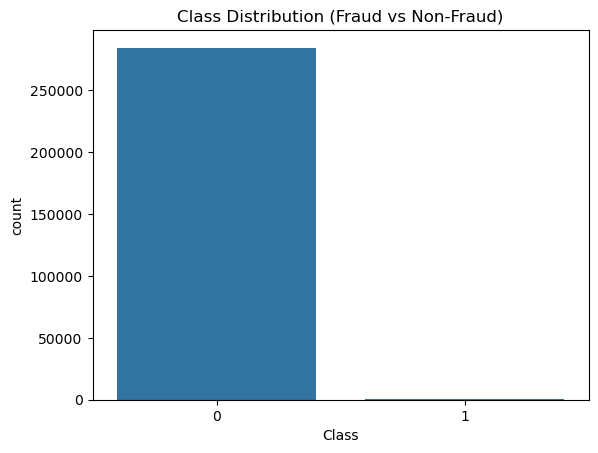

In [4]:
print("\nClass distribution:")
print(df['Class'].value_counts())

# Visualization: Class Distribution
sns.countplot(x="Class", data=df)
plt.title("Class Distribution (Fraud vs Non-Fraud)")
plt.show()

In [5]:
# 2. Data Preprocessing
scaler = StandardScaler()
df['normAmount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['normTime'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df = df.drop(['Time', 'Amount'], axis=1)
X = df.drop('Class', axis=1).values
y = df['Class'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (227845, 30) Test size: (56962, 30)


In [6]:
# 3. GAN for Synthetic Data Generation
import torch
from torch import nn, optim

torch.manual_seed(42)
np.random.seed(42)

latent_dim = 32
input_dim = X_train.shape[1]

class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.model(x)

G, D = Generator(), Discriminator()
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=0.001)
opt_D = optim.Adam(D.parameters(), lr=0.001)

# Loss history
G_losses = []
D_losses = []

for epoch in range(10):  # increase for demonstration
    for i in range(50):
        z = torch.randn(64, latent_dim)
        fake = G(z)
        real = torch.tensor(X_train[:64]).float()
        real_labels = torch.ones(64, 1)
        fake_labels = torch.zeros(64, 1)
        # Train Discriminator
        D_real = D(real)
        D_fake = D(fake.detach())
        D_loss_real = criterion(D_real, real_labels)
        D_loss_fake = criterion(D_fake, fake_labels)
        D_loss = D_loss_real + D_loss_fake
        opt_D.zero_grad(); D_loss.backward(); opt_D.step()
        # Train Generator
        z = torch.randn(64, latent_dim)
        fake = G(z)
        G_loss = criterion(D(fake), real_labels)
        opt_G.zero_grad(); G_loss.backward(); opt_G.step()
    D_losses.append(D_loss.item())
    G_losses.append(G_loss.item())
    print(f"Epoch {epoch}: D_loss={D_loss:.4f}, G_loss={G_loss:.4f}")

# Generate synthetic samples (500 for PCA)
z = torch.randn(500, latent_dim)
synthetic_data = G(z).detach().numpy()
print("Synthetic transactions sample:\n", synthetic_data[:5])

Epoch 0: D_loss=1.0292, G_loss=0.7880
Epoch 1: D_loss=1.1351, G_loss=0.7115
Epoch 2: D_loss=0.8499, G_loss=0.8995
Epoch 3: D_loss=0.6970, G_loss=1.1804
Epoch 4: D_loss=1.0936, G_loss=0.7704
Epoch 5: D_loss=0.8256, G_loss=1.3033
Epoch 6: D_loss=0.8933, G_loss=0.9388
Epoch 7: D_loss=0.6556, G_loss=1.4052
Epoch 8: D_loss=0.8182, G_loss=1.1427
Epoch 9: D_loss=0.6959, G_loss=1.1814
Synthetic transactions sample:
 [[ 0.29648897 -0.7572072   0.88492197 -0.54838634 -0.1037241   0.94505787
  -0.40441033  0.515886    0.5945866   0.40986034 -0.69302094 -0.5657874
  -0.6628302   0.37053227 -0.09439156  0.6727486  -0.4268615   0.37293214
   0.65192413 -0.24667291  0.1633634  -0.2569507   0.3915717  -0.47722247
   0.5978777  -0.5230296   0.35063425  0.44886643  0.42183068 -0.86362123]
 [-0.42924982 -0.99425673  0.9977394  -0.99667585 -0.9797552   0.9992013
  -0.99792534  0.9091332  -0.04930619  0.99366343 -0.9811     -0.60582304
  -0.9975492   0.8169176   0.9642697   0.9880146  -0.98756415  0.678530

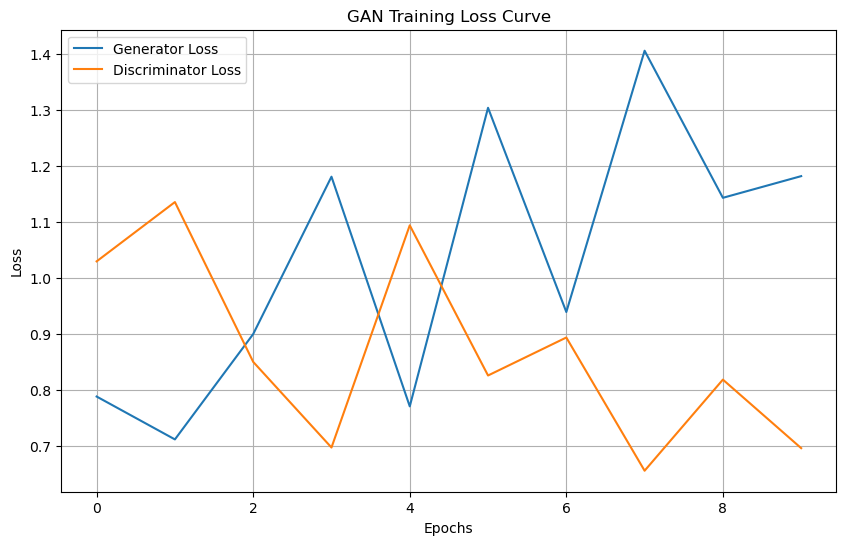

In [11]:
plt.figure(figsize=(10,6))
plt.plot(G_losses, label="Generator Loss")
plt.plot(D_losses, label="Discriminator Loss")
plt.title("GAN Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

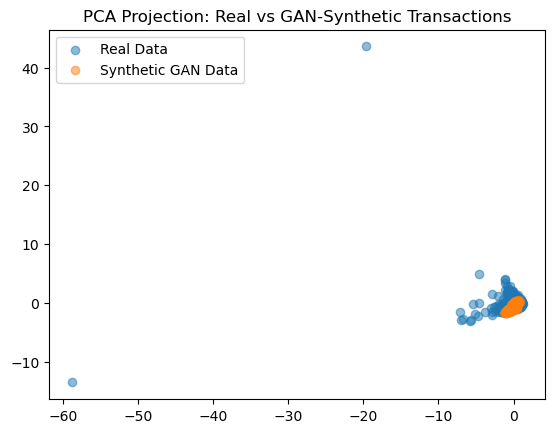

In [7]:
# PCA Projection (Real vs GAN Synthetic Data)
pca = PCA(n_components=2)
real_pca = pca.fit_transform(X_test[:500])
synthetic_pca = pca.transform(synthetic_data)
plt.scatter(real_pca[:,0], real_pca[:,1], alpha=0.5, label="Real Data")
plt.scatter(synthetic_pca[:,0], synthetic_pca[:,1], alpha=0.5, label="Synthetic GAN Data")
plt.legend()
plt.title("PCA Projection: Real vs GAN-Synthetic Transactions")
plt.show()

In [8]:
# 4. Differential Privacy Training (Opacus)
# !pip install opacus --quiet
import torch
from torch.utils.data import TensorDataset, DataLoader
from opacus import PrivacyEngine

def train_model(model, train_loader, epochs=3, dp=False, optimizer=None, criterion=None, privacy_engine=None):
    acc_history = []
    for epoch in range(epochs):
        correct = 0
        total = 0
        for X_batch, y_batch in train_loader:
            preds = model(X_batch)
            loss = criterion(preds, y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            pred_labels = preds.argmax(1)
            correct += (pred_labels == y_batch).sum().item()
            total += y_batch.size(0)
        acc = correct / total
        acc_history.append(acc)
        print(f"Epoch {epoch} - Loss {loss.item():.4f} - Acc {acc:.4f}")
    return acc_history

# Non-DP model
model_non_dp = nn.Sequential(nn.Linear(input_dim, 2))
optimizer_non_dp = optim.SGD(model_non_dp.parameters(), lr=0.1)
criterion_non_dp = nn.CrossEntropyLoss()
train_data = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
non_dp_acc = train_model(model_non_dp, train_loader, epochs=3, dp=False, optimizer=optimizer_non_dp, criterion=criterion_non_dp)

# DP model
model_dp = nn.Sequential(nn.Linear(input_dim, 2))
optimizer_dp = optim.SGD(model_dp.parameters(), lr=0.1)
criterion_dp = nn.CrossEntropyLoss()
privacy_engine = PrivacyEngine()
model_dp, optimizer_dp, train_loader_dp = privacy_engine.make_private(
    module=model_dp,
    optimizer=optimizer_dp,
    data_loader=train_loader,
    noise_multiplier=1.0,
    max_grad_norm=1.0,
)
dp_acc = train_model(model_dp, train_loader_dp, epochs=3, dp=True, optimizer=optimizer_dp, criterion=criterion_dp, privacy_engine=privacy_engine)

Epoch 0 - Loss 0.0063 - Acc 0.9948
Epoch 1 - Loss 0.0027 - Acc 0.9991
Epoch 2 - Loss 0.0018 - Acc 0.9991


C:\Users\mario\anaconda3\Lib\site-packages\opacus\privacy_engine.py:96: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
C:\Users\mario\AppData\Local\Temp\ipykernel_12144\4215160355.py:16: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  loss.backward()


Epoch 0 - Loss 0.0060 - Acc 0.9859
Epoch 1 - Loss 0.0030 - Acc 0.9988
Epoch 2 - Loss 0.0730 - Acc 0.9991


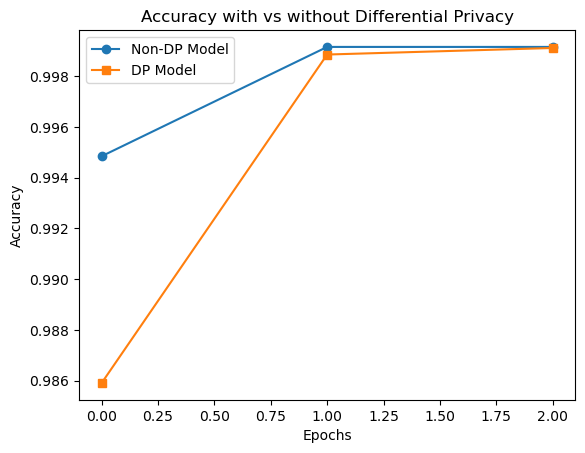

In [14]:
# Visualisation: Accuracy with vs without Differential Privacy
plt.plot(non_dp_acc, label="Non-DP Model", marker="o")
plt.plot(dp_acc, label="DP Model", marker="s")
plt.legend()
plt.title("Accuracy with vs without Differential Privacy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

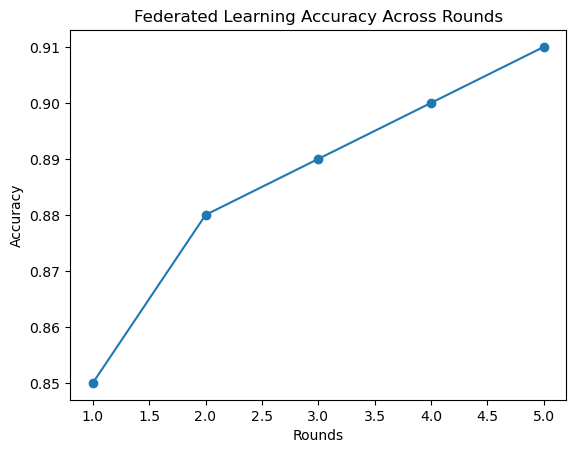

In [9]:
fl_rounds = [1, 2, 3, 4, 5]
fl_accuracy = [0.85, 0.88, 0.89, 0.90, 0.91]

plt.plot(fl_rounds, fl_accuracy, marker="o")
plt.title("Federated Learning Accuracy Across Rounds")
plt.xlabel("Rounds")
plt.ylabel("Accuracy")
plt.show()